In [16]:
import math
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt

In [17]:
# ──────────────────────────────────────────────
#  ФУНКЦИИ И ЕЕ ПРОИЗВОДНЫЕ
# ──────────────────────────────────────────────

def f(x: float) -> float:
    """f(x) = ctg(x) - x/5"""
    return 1.0 / math.tan(x) - x / 5.0
 
 
def f_prime(x: float) -> float:
    """f'(x) = -1/sin²(x) - 1/5"""
    return -1.0 / math.sin(x) ** 2 - 1.0 / 5.0
 
 
def f_double_prime(x: float) -> float:
    """f''(x) = 2·cos(x)/sin³(x)"""
    return 2.0 * math.cos(x) / math.sin(x) ** 3

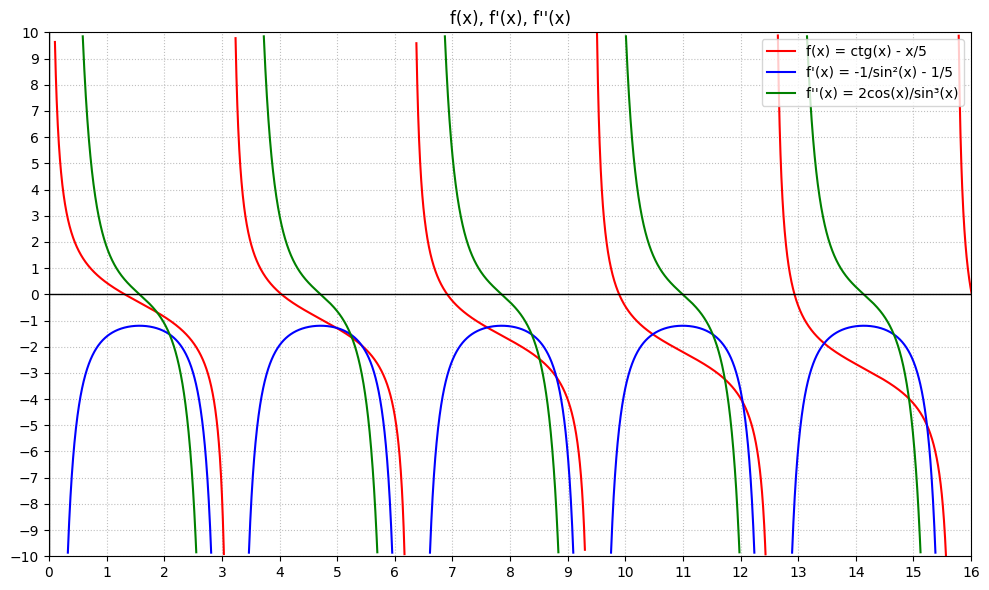

In [18]:
plt.figure(figsize=(10, 6))

for func, color, label in [
    (f,             'red',   "f(x) = ctg(x) - x/5"),
    (f_prime,       'blue',  "f'(x) = -1/sin²(x) - 1/5"),
    (f_double_prime,'green', "f''(x) = 2cos(x)/sin³(x)"),
]:
    for k in range(6):
        a = math.pi * k + 0.05
        b = math.pi * (k + 1) - 0.05
        n = 800
        xs = [a + i * (b - a) / n for i in range(n + 1)]
        ys = [func(x) if abs(func(x)) <= 10 else None for x in xs]
        plt.plot(xs, ys, color=color, label=label if k == 0 else '')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle=':', alpha=0.8)

plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(1))

plt.xlim(0, 16)
plt.ylim(-10, 10)
plt.title("f(x), f'(x), f''(x)")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
# ──────────────────────────────────────────────
#  ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ──────────────────────────────────────────────
def separate_roots(x_min=0.01, x_max=16.0, step=0.05):
    intervals = []
    prev_x, prev_fx = None, None
    x = x_min
    while x <= x_max:
        # Контангес уходит в ±∞ при x = πk. 
        # 0.15 взят экспериментально, чтобы не пропустить корни, близкие к этим точкам
        k = round(x / math.pi)
        if abs(x - k * math.pi) < 0.15:
            x += step
            prev_x = prev_fx = None
            continue
        fx = f(x)

        # Если функция меняет знак, значит в этом интервале есть корни. Запоминаем его
        if prev_fx is not None and prev_fx * fx < 0:
            intervals.append((round(prev_x, 4), round(x, 4)))
        
        # Cохраняем текущее значение для следующей итерации
        prev_x, prev_fx = x, fx
        x = round(x + step, 6)
    return intervals

Видео по которому взял теорию <br/>
https://youtu.be/BaLwroc_cbY?si=qbG0GqQtJIQCvZt_

In [20]:
# ──────────────────────────────────────────────
#  1. МЕТОД ДИХОТОМИИ
# ──────────────────────────────────────────────
def dichotomy(a: float, b: float, eps: float = 1e-6) -> tuple[float, int]:
    """
    Метод деления пополам
    Начальное приближение: выбрать [a, b] так, чтобы f(a)·f(b) < 0
    Остановка: (b - a) / 2 < eps
    """
    # a и b должны быть разного знака
    if f(a) * f(b) >= 0:
        raise ValueError(f"f(a)·f(b) > 0 на [{a}, {b}] — корень не гарантирован.")
    
    # Счетчик количества итераций
    n = 0

    # Считаем до тех пор, пока длина интервала не станет меньше 2·eps
    # Когда (b - a) / 2 < eps, значит коренем будет являтся серединой интервала [a, b]
    while (b - a) / 2.0 > eps:
        # Находим половину промежутка и значение функции в этой точке
        c = (a + b) / 2.0
        fc = f(c)

        # Если f(a)·f(c) ≤ 0  →  корень на [a, c]  →  b = c
        # Если f(a)·f(c) > 0  →  корень на [c, b]  →  a = c
        if f(a) * fc <= 0:
            b = c
        else:
            a = c

        n += 1
    
    root = (a + b) / 2.0

    return root, n


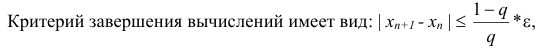 <br/>
Видео по которому взял теорию <br/>
https://youtu.be/hAAJ6G8zzjM?si=Xer7CGxb24LCd746

In [21]:
# ──────────────────────────────────────────────
#  2. МЕТОД ПРОСТОЙ ИТЕРАЦИИ
# ──────────────────────────────────────────────

def simple_iteration(x0: float, eps: float = 1e-4) -> tuple[float, int]:
    """
    Метод простой итерации

    Изменим форму соей фции на x = φ(x)
    f(x) = ctg(x) - x/5 = 0  →  ctg(x) = x/5  →  arccot(x/5) = x
    Не любая функция может быть преобразована в виде x = φ(x), но для нашей функции это возможно

    φ(x) = arccot(x/5)  →  x_{n+1} = φ(x_n)
    Остановка: |x_{n+1} - x_n| < eps
    """
 
    def phi(x: float) -> float:
        # arccot(x/5) = arctan(5/x) = atan2(1, x/5)
        # Используем atan2, чтобы корректно обрабатывать случаи, когда x/5 близко к нулю
        return math.atan2(1.0, x / 5.0)
 
    # Предполагаемый корень
    x = x0
    # Счетчик количества итераций
    n = 0
    while n < 500:
        xn = phi(x)
        if abs(xn - x) < eps:
            x = xn
            n += 1
            break
        x = xn
        n += 1
 
    return x, n

In [22]:
# ──────────────────────────────────────────────
#  3. МЕТОД НЬЮТОНА (КАСАТЕЛЬНЫХ)
# ──────────────────────────────────────────────

def newton(x0: float, eps: float = 1e-4) -> tuple[float, int]:
    """
    Метод Ньютона
    
    x_{n+1} = x_n - f(x_n) / f'(x_n)
    Остановка: |x_{n+1} - x_n| < eps.
    Квадратичная сходимость.
    """

    x = x0
    n = 0
    while n < 50:
        fx = f(x)   
        fpx = f_prime(x)
        if abs(fpx) < 1e-14:
            print(f"(x) ≈ 0, метод Ньютона не применим")
            break
        xn = x - fx / fpx
        if abs(xn - x) < eps:
            x = xn
            n += 1
            break
        x = xn
        n += 1

    return x, n


In [23]:
# ──────────────────────────────────────────────
#  4. МЕТОД ХОРД (СЕКУЩИХ)
# ──────────────────────────────────────────────

def chord(a: float, b: float, eps: float = 1e-4) -> tuple[float, int]:
    """
    Метод хорд
    Фиксируем конец, где f·f'' > 0; подвижный конец сходится к корню
    Остановка: |f(c)| < eps
    """
    if f(a) * f(b) > 0:
        raise ValueError(f"f(a)·f(b) > 0 на [{a}, {b}].")

    # определяем фиксированный конец
    fix_a = f(a) * f_double_prime(a) > 0

    n = 0
    while n < 200:
        fa, fb = f(a), f(b)
        c = a - fa * (b - a) / (fb - fa)
        fc = f(c)
        if abs(fc) < eps:
            n += 1
            break
        if fix_a:
            if fc * fa < 0:
                b = c
            else:
                a = c
        else:
            if fc * fb < 0:
                a = c
            else:
                b = c
        n += 1

    root = a - f(a) * (b - a) / (f(b) - f(a))

    return root, n

In [24]:
# ──────────────────────────────────────────────
#  5. МЕТОД ЧЕБЫШЕВА
# ──────────────────────────────────────────────

def chebyshev(x0: float, eps: float = 1e-4) -> tuple[float, int]:
    """
    Метод Чебышева (кубическая сходимость).
    x_{n+1} = x_n - f/f' - (f²·f'') / (2·(f')³)
    Остановка: |x_{n+1} - x_n| < eps.
    """

    x = x0
    n = 0
    while n < 30:
        fx = f(x)
        fpx = f_prime(x)
        fppx = f_double_prime(x)
        if abs(fpx) < 1e-14:
            raise ZeroDivisionError("f'(x) ≈ 0.")
        xn = x - fx / fpx - (fx ** 2 * fppx) / (2.0 * fpx ** 3)
        if abs(xn - x) < eps:
            x = xn
            n += 1
            break
        x = xn
        n += 1

    return x, n

In [28]:
# ──────────────────────────────────────────────
#  ГЛАВНАЯ ПРОГРАММА
# ──────────────────────────────────────────────
def main():
    EPS = 1e-4

# ── Шаг 1: отделение корней ───────────────────
    print("\n" + "=" * 60)
    print("  f(x) = ctg(x) − x/5 = 0")
    print("=" * 60)
    intervals = separate_roots()
    print(f"  Найдено интервалов со сменой знака: {len(intervals)}")
    print(f"\n  {'Интервал':<20} {'f(a)':>10} {'f(b)':>10}")
    print("  " + "-" * 42)
    for a, b in intervals:
        print(f"  [{a}, {b}]{'':<8} {f(a):>10.4f} {f(b):>10.4f}")

    # Берём первые два корня для демонстрации всех методов
    if len(intervals) < 2:
        print("Недостаточно интервалов!")
        return
    
    a1, b1 = intervals[0]
    a2, b2 = intervals[1]
    x01 = (a1 + b1) / 2   # начальное приближение для корня 1
    x02 = (a2 + b2) / 2   # начальное приближение для корня 2

    print(f"\n  Уточняем корень 1 на [{a1}, {b1}]  (x₀ = {x01:.4f})")
    print(f"  Уточняем корень 2 на [{a2}, {b2}]  (x₀ = {x02:.4f})")

# ── Шаг 2: корень 1 ───────────────────────────

    print("\n" + "=" * 60)
    print("  КОРЕНЬ 1")
    print("=" * 60)
 
    r1_d,  n1_d  = dichotomy(a1, b1, EPS)
    r1_i,  n1_i  = simple_iteration(x01, EPS)
    r1_n,  n1_n  = newton(x01, EPS)
    r1_c,  n1_c  = chord(a1, b1, EPS)
    r1_ch, n1_ch = chebyshev(x01, EPS)

    print('  Дихотомия: корень = {:.6f}, итераций = {}'.format(r1_d, n1_d))
    print('  Простая итерация: корень = {:.6f}, итераций = {}'.format(r1_i, n1_i))
    print('  Метод Ньютона: корень = {:.6f}, итераций = {}'.format(r1_n, n1_n))
    print('  Метод хорд: корень = {:.6f}, итераций = {}'.format(r1_c, n1_c))
    print('  Метод Чебышева: корень = {:.6f}, итераций = {}'.format(r1_ch, n1_ch))

# ── Шаг 3: корень 2 ───────────────────────────

    print("\n" + "=" * 60)
    print("  КОРЕНЬ 2")
    print("=" * 60)

    r2_d,  n2_d  = dichotomy(a2, b2, EPS)
    r2_i,  n2_i  = simple_iteration(x02, EPS)
    r2_n,  n2_n  = newton(x02, EPS)
    r2_c,  n2_c  = chord(a2, b2, EPS)
    r2_ch, n2_ch = chebyshev(x02, EPS)

    print('  Дихотомия: корень = {:.6f}, итераций = {}'.format(r2_d, n2_d))
    print('  Простая итерация: корень = {:.6f}, итераций = {}'.format(r2_i, n2_i))
    print('  Метод Ньютона: корень = {:.6f}, итераций = {}'.format(r2_n, n2_n))
    print('  Метод хорд: корень = {:.6f}, итераций = {}'.format(r2_c, n2_c))
    print('  Метод Чебышева: корень = {:.6f}, итераций = {}'.format(r2_ch, n2_ch))

if __name__ == "__main__":
    main()




  f(x) = ctg(x) − x/5 = 0
  Найдено интервалов со сменой знака: 5

  Интервал                   f(a)       f(b)
  ------------------------------------------
  [1.31, 1.36]             0.0049    -0.0580
  [4.01, 4.06]             0.0444    -0.0480
  [6.86, 6.91]             0.1650    -0.0013
  [9.86, 9.91]             0.1787    -0.0854
  [12.91, 12.96]             0.2127    -0.1841

  Уточняем корень 1 на [1.31, 1.36]  (x₀ = 1.3350)
  Уточняем корень 2 на [4.01, 4.06]  (x₀ = 4.0350)

  КОРЕНЬ 1
  Дихотомия: корень = 1.313809, итераций = 8
  Простая итерация: корень = 1.313833, итераций = 5
  Метод Ньютона: корень = 1.313838, итераций = 2
  Метод хорд: корень = 1.313875, итераций = 1
  Метод Чебышева: корень = 1.313838, итераций = 2

  КОРЕНЬ 2
  Дихотомия: корень = 4.033535, итераций = 8
  Простая итерация: корень = 1.313841, итераций = 8
  Метод Ньютона: корень = 4.033568, итераций = 2
  Метод хорд: корень = 4.033575, итераций = 2
  Метод Чебышева: корень = 4.033568, итераций = 2
